# **02 - Exploratory Data Analysis**

## Objectives

- Load and inspect the cleaned Online Retail Transaction dataset.
- Explore overall revenue and sales performance.
- Analyse revenue and sales volume over time.
- Investigate product and customer purchasing patterns.
- Compare geographic performance across countries.
- Explore relevant distributions and relationships within the data.
- Identify key insights that can support further visualisation and machine learning analysis.

## Inputs

- Cleaned Online Retail Transaction dataset produced during the ETL process and stored in the `outputs` folder.

## Outputs

- Exploratory analysis of the Online Retail Transaction dataset.
- Key findings and visualisations relating to revenue, sales volume, customers, products and geographic performance.
- Insights to support subsequent stages of the project.

## Additional Comments

- Analysis will be exploratory, with findings and interpretations documented throughout the notebook.

---

# Change working directory

In [213]:
import os

current_dir = os.getcwd()
print("Current directory:", current_dir)

if os.path.basename(current_dir) == "jupyter_notebooks":
    os.chdir(os.path.dirname(current_dir))
elif os.path.basename(current_dir) == "vscode-projects":
    os.chdir("Online Retail Transaction Analysis")

current_dir = os.getcwd()
print("Working directory set to:", current_dir)

Current directory: /Users/sahraosman/Documents/vscode-projects/Online Retail Transaction Analysis
Working directory set to: /Users/sahraosman/Documents/vscode-projects/Online Retail Transaction Analysis


---

# Section 1 -  Import libraries

Here I will be importing the libraries that I will be using in this notebook.

In [214]:
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
import seaborn as sns
from matplotlib.ticker import FuncFormatter
from scipy.stats import mannwhitneyu

sns.set_theme(style="whitegrid")


---

# Section 2 - Load the dataset

Here I will load the cleaned Online Retail Transaction dataset that was produced during the ETL process.

In [215]:
df = pd.read_csv("outputs/Online_Retail_Cleaned.csv")

/var/folders/cx/w0ydrn213c14xglf6wmp_2l00000gn/T/ipykernel_86670/3308739013.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("outputs/Online_Retail_Cleaned.csv")


In [216]:
df.dtypes

InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID       int64
Country         object
Revenue        float64
dtype: object

The initial import produced a mixed data type warning for `InvoiceNo`. Inspection of the imported data types also showed that `InvoiceDate` had been loaded as an object rather than a datetime.

In [217]:
df["InvoiceNo"].apply(type).value_counts()

InvoiceNo
<class 'int'>    459342
<class 'str'>     65536
Name: count, dtype: int64

Further inspection showed that `InvoiceNo` contained both integer and string values. Since invoice numbers are identifiers rather than numerical measures, the column will be explicitly loaded as a string. `InvoiceDate` will also be parsed as a datetime to support time-based analysis.

In [218]:
df = pd.read_csv(
    "outputs/Online_Retail_Cleaned.csv",
    dtype={"InvoiceNo": str},
    parse_dates=["InvoiceDate"],
)

In [219]:
df.dtypes

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID              int64
Country                object
Revenue               float64
dtype: object

In [220]:
df["InvoiceNo"].apply(type).value_counts()

InvoiceNo
<class 'str'>    524878
Name: count, dtype: int64

The corrected import confirms that all `InvoiceNo` values are now consistently loaded as strings and `InvoiceDate` has been successfully parsed as a datetime. The cleaned dataset is now loaded with appropriate data types for exploratory analysis.

In [221]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [222]:
print("Number of rows: ", df.shape[0])

Number of rows:  524878


In [223]:
print("Number of columns: ", df.shape[1])

Number of columns:  9


The dataset contains 524,878 records and 9 columns, matching the final dataset produced during the ETL process. An initial preview also confirms that the cleaned data and engineered `Revenue` feature have loaded successfully and are ready for exploratory analysis.

---

# Section 3 - Overall Business Performance

In this section, I will explore the overall business performance of the Online Retail Transaction dataset. This will include an analysis of total revenue, sales volume and other key metrics to provide an overview of the business's performance.

In [224]:
total_revenue = df["Revenue"].sum()
print(f"Total Revenue: {total_revenue:,.2f}")

Total Revenue: 10,642,110.80


The total revenue generated across the cleaned transaction records is £10,642,110.80. This provides an overall measure of the revenue represented within the dataset and will be explored further across time periods, products, customers and countries.

In [225]:
total_sales_volume = df["Quantity"].sum()
print(f"Total Sales Volume: {total_sales_volume:,}")

Total Sales Volume: 5,572,420


A total of 5,572,420 units were sold across the cleaned transaction records. This represents the overall sales volume within the dataset and can later be explored across time periods, products and countries.

In [226]:
total_transactions = df["InvoiceNo"].nunique()
unique_customers = df["CustomerID"].nunique()

print(f"Total Transactions: {total_transactions:,}")
print(f"Unique Customers: {unique_customers:,}")

Total Transactions: 19,960
Unique Customers: 4,338


The dataset contains 19,960 unique transactions across 4,338 unique customers. The difference between these figures indicates that customers can make multiple transactions, which will be investigated further during the customer purchasing behaviour analysis.

In [227]:
average_transaction = total_revenue / total_transactions

print(f"Average Transaction Value: {average_transaction:,.2f}")

Average Transaction Value: 533.17


The average transaction value across the dataset is £533.17. This represents the mean revenue generated per unique transaction. However, the average may be influenced by higher-value transactions, so the distribution of transaction values will be explored further during the analysis.

To provide a clear overview of the key business performance metrics calculated above, the results are summarised in a single DataFrame.

In [228]:
business_summary = pd.DataFrame(
    {
        "Metric": [
            "Total Revenue",
            "Total Sales Volume",
            "Total Transactions",
            "Unique Customers",
            "Average Transaction Value",
        ],
        "Value": [
            total_revenue,
            total_sales_volume,
            total_transactions,
            unique_customers,
            average_transaction,
        ],
    }
)
business_summary

,Metric,Value
0,Total Revenue,1.064211e+07
1,Total Sales Volume,5.572420e+06
2,Total Transactions,1.996000e+04
3,Unique Customers,4.338000e+03
4,Average Transaction Value,5.331719e+02


Overall, the dataset contains transactions generating a total revenue of £10,642,110.80 from 5,572,420 units sold across 19,960 transactions and 4,338 unique customers. The average transaction value is £533.17. These metrics provide a baseline for further analysis of how performance varies over time, across products, customers and geographic regions.

---

# Section 4 - Revenue and Sales Volume Over Time

In this section, I will analyse how revenue and sales volume change over time. The transaction date range will first be examined to understand the period covered by the dataset. Monthly revenue and sales volume will then be analysed to identify trends, fluctuations and periods of higher or lower sales activity.

In [229]:
df["InvoiceDate"].min()

Timestamp('2010-12-01 08:26:00')

In [230]:
df["InvoiceDate"].max()

Timestamp('2011-12-09 12:50:00')

The dataset covers transactions from 1 December 2010 to 9 December 2011. This provides approximately one year of transaction data; however, December 2011 contains only partial-month data. This will be considered when interpreting monthly revenue and sales volume trends.

In [231]:
df["YearMonth"] = df["InvoiceDate"].dt.to_period("M")

In [232]:
df[["InvoiceDate", "YearMonth"]].head()

,InvoiceDate,YearMonth
0,2010-12-01 08:26:00,2010-12
1,2010-12-01 08:26:00,2010-12
2,2010-12-01 08:26:00,2010-12
3,2010-12-01 08:26:00,2010-12
4,2010-12-01 08:26:00,2010-12


A `YearMonth` feature was created from `InvoiceDate` to support monthly trend analysis. Including both the year and month ensures that transactions from December 2010 and December 2011 are treated as separate periods.

In [233]:
df.groupby("YearMonth")["Revenue"].sum().reset_index()

,YearMonth,Revenue
0,2010-12,821452.730
1,2011-01,689811.610
2,2011-02,522545.560
3,2011-03,716215.260
4,2011-04,536968.491
5,2011-05,769296.610
6,2011-06,760547.010
7,2011-07,718076.121
8,2011-08,757841.380
9,2011-09,1056435.192


In [234]:
monthly_performance = (
    df.groupby("YearMonth")[["Revenue", "Quantity"]].sum().reset_index()
)
monthly_performance

,YearMonth,Revenue,Quantity
0,2010-12,821452.730,358019
1,2011-01,689811.610,387099
2,2011-02,522545.560,282934
3,2011-03,716215.260,376599
4,2011-04,536968.491,307953
5,2011-05,769296.610,395001
6,2011-06,760547.010,388511
7,2011-07,718076.121,399693
8,2011-08,757841.380,421020
9,2011-09,1056435.192,569573


In [235]:
monthly_performance.dtypes

YearMonth    period[M]
Revenue        float64
Quantity         int64
dtype: object

The `YearMonth` column is stored as a pandas Period data type. To ensure compatibility with Seaborn when plotting the monthly trends, the column will be converted to a string for use as the x-axis labels.

In [236]:
monthly_performance["YearMonth"] = monthly_performance["YearMonth"].astype(str)

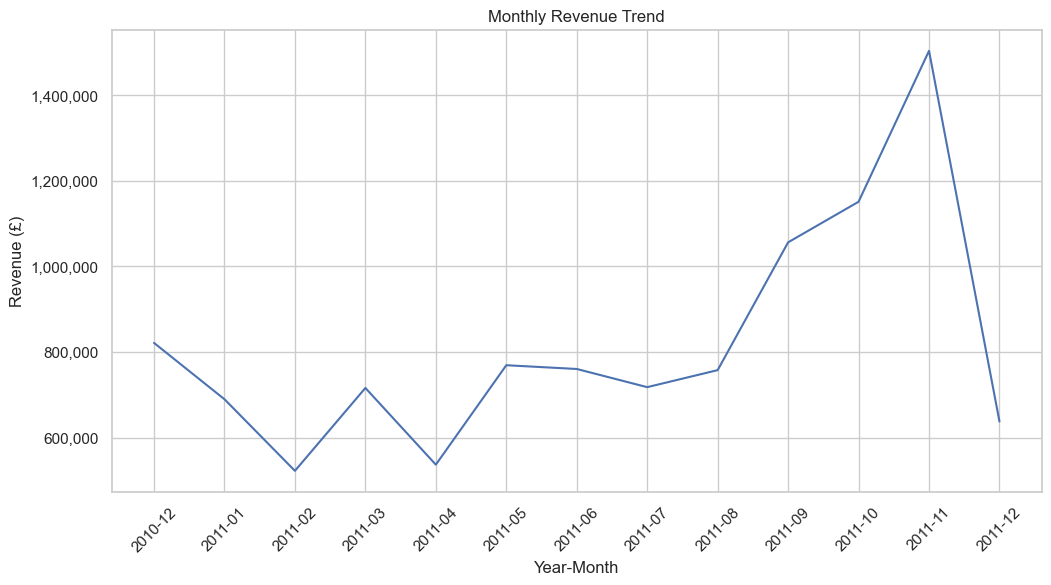

In [237]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_performance, x="YearMonth", y="Revenue")
plt.title("Monthly Revenue Trend")
plt.xlabel("Year-Month")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45)
revenue_formatter = FuncFormatter(lambda x, _: f"{x:,.0f}")
plt.gca().yaxis.set_major_formatter(revenue_formatter)
plt.show()

Monthly revenue fluctuates throughout the first half of the period, declining from December 2010 to February 2011 before recovering in March. Revenue falls again in April, followed by a stronger increase in May and relatively smaller fluctuations through to August.

A more substantial increase is visible from August onwards, with revenue rising sharply in September and continuing to increase through October before reaching its highest level in November 2011. This suggests that the strongest revenue performance within the complete monthly periods occurred towards the later months of 2011.

Revenue appears to fall substantially in December 2011; however, this should not be interpreted as a genuine decline in performance because the dataset only contains transactions up to 9 December. December 2011 is therefore an incomplete month and is not directly comparable with the complete monthly periods.

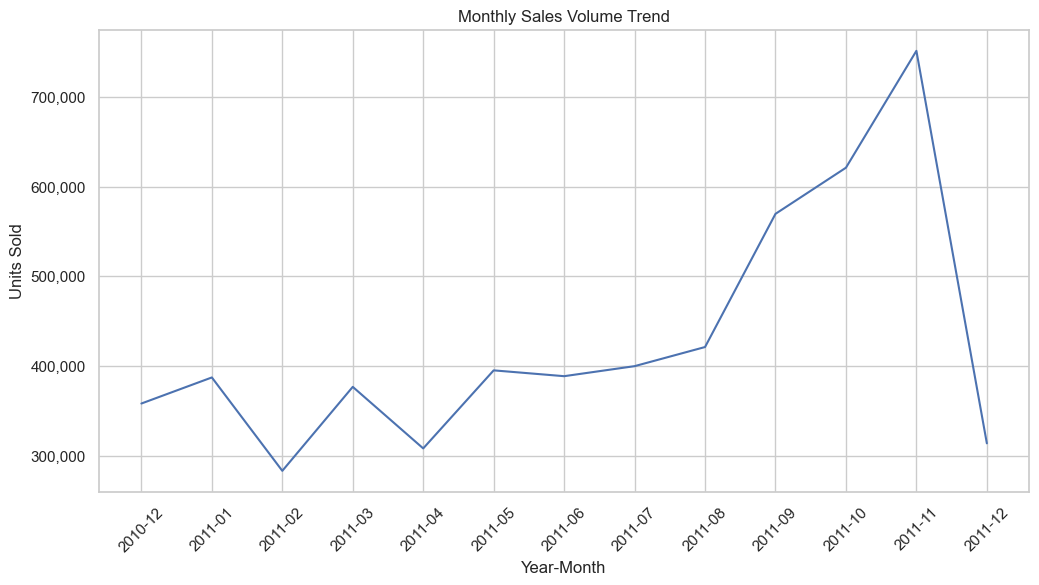

In [238]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_performance, x="YearMonth", y="Quantity")
plt.title("Monthly Sales Volume Trend")
plt.xlabel("Year-Month")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)
quantity_formatter = FuncFormatter(lambda x, _: f"{x:,.0f}")
plt.gca().yaxis.set_major_formatter(quantity_formatter)
plt.show()

Monthly sales volume broadly follows a similar pattern to revenue, although the two measures do not move together in every period. Sales volume increases from December 2010 to January 2011 despite revenue decreasing over the same period. This is followed by a decline in February, an increase in March and another decline in April.

Sales volume recovers in May and remains relatively stable with smaller fluctuations through to August. From August onwards, sales activity increases substantially, with a sharp rise in September followed by further growth through October and November. November 2011 records the highest sales volume within the dataset.

The overall similarity between the revenue and sales volume trends suggests that higher quantities sold are generally associated with higher monthly revenue. However, periods such as December 2010 to January 2011 show that the relationship is not exact, suggesting that factors such as product prices and the mix of products purchased may also influence monthly revenue. The apparent decline in December 2011 should again be interpreted cautiously because the dataset only contains transactions up to 9 December.

---

# Section 5 - Product Performance

In this section, I will analyse product performance by examining sales volume, transaction frequency and revenue. This will help identify the strongest-performing products and determine whether high sales volumes reflect consistent demand or are influenced by unusually large individual orders.

In [239]:
unique_stock_codes = df["StockCode"].nunique()

In [240]:
unique_descriptions = df["Description"].nunique()

In [241]:
print(f"Unique Stock Codes: {unique_stock_codes:,}")
print(f"Unique Product Descriptions: {unique_descriptions:,}")

Unique Stock Codes: 3,922
Unique Product Descriptions: 4,026


In [242]:
stockcode_descriptions = df.groupby("StockCode")["Description"].nunique().reset_index()
stockcode_descriptions

,StockCode,Description
0,10002,1
1,10080,1
2,10120,1
3,10123C,1
4,10124A,1
...,...,...
3917,gift_0001_20,1
3918,gift_0001_30,1
3919,gift_0001_40,1
3920,gift_0001_50,1


In [243]:
stockcode_descriptions[stockcode_descriptions["Description"] > 1].sort_values(
    "Description", ascending=False
).head()

,StockCode,Description
2089,23236,4
2049,23196,4
104,17107D,3
1980,23126,3
2062,23209,3


In [244]:
df[df["StockCode"] == "23236"]["Description"].unique()

array(['DOILEY STORAGE TIN', 'DOILEY BISCUIT TIN',
       'STORAGE TIN VINTAGE DOILEY ', 'STORAGE TIN VINTAGE DOILY '],
      dtype=object)

In [245]:
df[df["StockCode"] == "23196"]["Description"].unique()

array(['RETRO LEAVES MAGNETIC NOTEPAD',
       'RETO LEAVES MAGNETIC SHOPPING LIST',
       'LEAVES MAGNETIC  SHOPPING LIST', 'VINTAGE LEAF MAGNETIC NOTEPAD'],
      dtype=object)

In [246]:
df[df["StockCode"] == "17107D"]["Description"].unique()

array(["FLOWER FAIRY,5 SUMMER B'DRAW LINERS",
       'FLOWER FAIRY 5 DRAWER LINERS',
       'FLOWER FAIRY 5 SUMMER DRAW LINERS'], dtype=object)

Before analysing product performance, `StockCode` and `Description` were examined to determine the most appropriate product identifier. The dataset contains 3,922 unique StockCodes and 4,026 unique product descriptions. Further investigation showed that some StockCodes are associated with multiple description variations. Therefore, `StockCode` will be used as the primary product identifier, while `Description` will be used to provide readable product labels.

In [247]:
top_products_quantity = (
    df.groupby("StockCode")["Quantity"]
    .agg(["sum", "max"])
    .reset_index()
    .sort_values("sum", ascending=False)
    .head()
)
top_products_quantity

,StockCode,sum,max
2465,23843,80995,80995
2020,23166,78033,74215
1109,22197,56898,4300
2909,84077,54951,4800
3387,85099B,48371,1200


In [248]:
(top_products_quantity["max"] / top_products_quantity["sum"]) * 100

2465    100.000000
2020     95.107198
1109      7.557383
2909      8.735055
3387      2.480825
dtype: float64

In [249]:
top_products_quantity["LargestOrderPercentage"] = (
    (top_products_quantity["max"] / top_products_quantity["sum"]) * 100
).round(2)
top_products_quantity

,StockCode,sum,max,LargestOrderPercentage
2465,23843,80995,80995,100.00
2020,23166,78033,74215,95.11
1109,22197,56898,4300,7.56
2909,84077,54951,4800,8.74
3387,85099B,48371,1200,2.48


Since total quantity sold can be influenced by unusually large individual orders, transaction frequency will also be examined to provide an indication of how consistently products are purchased across separate transactions.

In [250]:
product_transactions = (
    df.groupby("StockCode")["InvoiceNo"]
    .nunique()
    .reset_index()
    .sort_values("InvoiceNo", ascending=False)
    .head()
)
product_transactions

,StockCode,InvoiceNo
3407,85123A,2198
3387,85099B,2089
1310,22423,1988
2670,47566,1685
175,20725,1565


In [251]:
df[df["StockCode"] == "85099B"]["Description"].mode()

0    JUMBO BAG RED RETROSPOT
Name: Description, dtype: object

In [252]:
product_descriptions = (
    df.groupby("StockCode")["Description"].agg(lambda x: x.mode().iloc[0]).reset_index()
)

product_descriptions

,StockCode,Description
0,10002,INFLATABLE POLITICAL GLOBE
1,10080,GROOVY CACTUS INFLATABLE
2,10120,DOGGY RUBBER
3,10123C,HEARTS WRAPPING TAPE
4,10124A,SPOTS ON RED BOOKCOVER TAPE
...,...,...
3917,gift_0001_20,Dotcomgiftshop Gift Voucher £20.00
3918,gift_0001_30,Dotcomgiftshop Gift Voucher £30.00
3919,gift_0001_40,Dotcomgiftshop Gift Voucher £40.00
3920,gift_0001_50,Dotcomgiftshop Gift Voucher £50.00


In [253]:
product_transactions = product_transactions.merge(product_descriptions, on="StockCode")

product_transactions

,StockCode,InvoiceNo,Description
0,85123A,2198,WHITE HANGING HEART T-LIGHT HOLDER
1,85099B,2089,JUMBO BAG RED RETROSPOT
2,22423,1988,REGENCY CAKESTAND 3 TIER
3,47566,1685,PARTY BUNTING
4,20725,1565,LUNCH BAG RED RETROSPOT


In [254]:
top_products_quantity = top_products_quantity.merge(
    product_descriptions, on="StockCode"
)

top_products_quantity

,StockCode,sum,max,LargestOrderPercentage,Description
0,23843,80995,80995,100.00,"PAPER CRAFT , LITTLE BIRDIE"
1,23166,78033,74215,95.11,MEDIUM CERAMIC TOP STORAGE JAR
2,22197,56898,4300,7.56,POPCORN HOLDER
3,84077,54951,4800,8.74,WORLD WAR 2 GLIDERS ASSTD DESIGNS
4,85099B,48371,1200,2.48,JUMBO BAG RED RETROSPOT


The products with the highest total sales volume are not necessarily the products with the broadest repeated demand. The two highest-ranked products by quantity are heavily influenced by unusually large individual orders, with the largest transaction accounting for 100% and 95.11% of their total sales volume respectively. In contrast, the remaining top products have much lower largest-order shares, suggesting their sales volumes are distributed across a wider range of transactions.

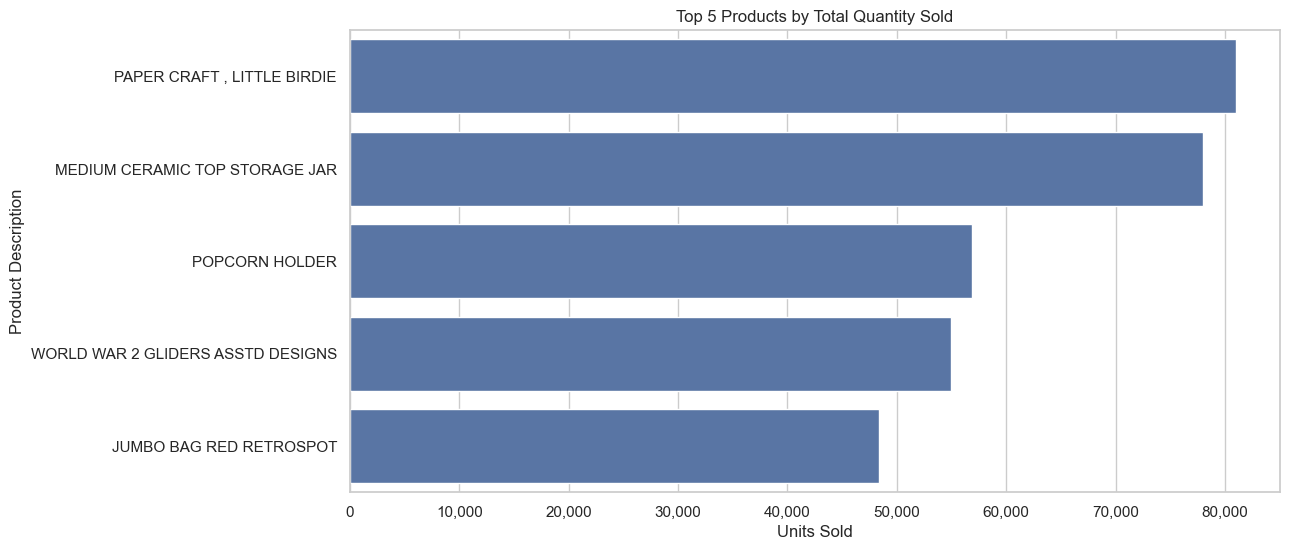

In [255]:
plt.figure(figsize=(12, 6))

sns.barplot(data=top_products_quantity, x="sum", y="Description")
quantity_formatter = FuncFormatter(lambda x, _: f"{x:,.0f}")
plt.gca().xaxis.set_major_formatter(quantity_formatter)
plt.title("Top 5 Products by Total Quantity Sold")
plt.xlabel("Units Sold")
plt.ylabel("Product Description")
plt.show()


PAPER CRAFT, LITTLE BIRDIE records the highest total sales volume at 80,995 units, followed by MEDIUM CERAMIC TOP STORAGE JAR at 78,033 units. However, these rankings are heavily influenced by unusually large individual orders, with the largest transaction accounting for 100% and 95.11% of their respective total sales volumes. In comparison, the remaining top products have much lower largest-order percentages, suggesting that their sales volumes are distributed more broadly across transactions.

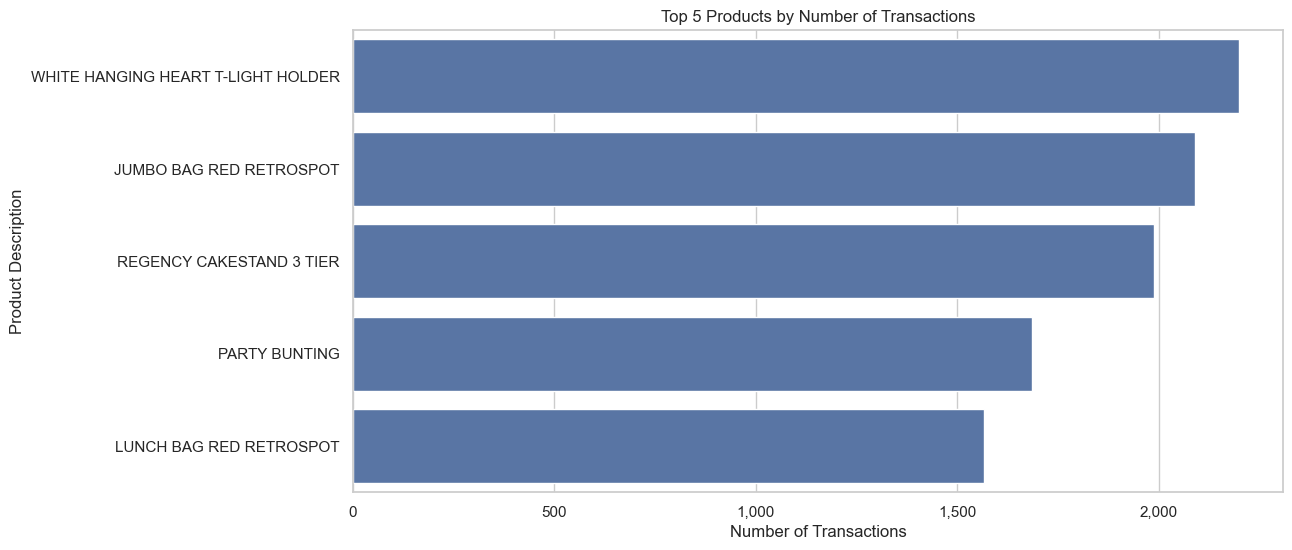

In [256]:
plt.figure(figsize=(12, 6))

sns.barplot(data=product_transactions, x="InvoiceNo", y="Description")
transaction_formatter = FuncFormatter(lambda x, _: f"{x:,.0f}")
plt.gca().xaxis.set_major_formatter(transaction_formatter)
plt.title("Top 5 Products by Number of Transactions")
plt.xlabel("Number of Transactions")
plt.ylabel("Product Description")
plt.show()

Analysis of transaction frequency shows a different pattern from total sales volume. WHITE HANGING HEART T-LIGHT HOLDER appeared in the greatest number of unique transactions at 2,198, followed by JUMBO BAG RED RETROSPOT at 2,089 and REGENCY CAKESTAND 3 TIER at 1,988. The two products with the highest total quantities sold do not appear among the products with the highest transaction frequency, supporting the earlier finding that their sales volumes were heavily influenced by unusually large individual orders. JUMBO BAG RED RETROSPOT appears in both top-five rankings, indicating both high overall sales volume and frequent purchasing across transactions.

Product performance will also be examined by revenue to identify which products contribute the greatest monetary value, rather than focusing only on sales volume and purchasing frequency.

In [257]:
top_products_revenue = (
    df.groupby("StockCode")["Revenue"]
    .sum()
    .reset_index()
    .sort_values(by="Revenue", ascending=False)
    .head()
)
top_products_revenue

,StockCode,Revenue
3911,DOT,206248.77
1310,22423,174156.54
2465,23843,168469.60
3407,85123A,104462.75
2670,47566,99445.23


In [258]:
df[df["StockCode"] == "DOT"]["Description"].unique()

array(['DOTCOM POSTAGE'], dtype=object)

In [259]:
top_products_revenue = (
    df[df["StockCode"] != "DOT"]
    .groupby("StockCode")["Revenue"]
    .sum()
    .reset_index()
    .sort_values(by="Revenue", ascending=False)
    .head()
)

top_products_revenue

,StockCode,Revenue
1310,22423,174156.54
2465,23843,168469.60
3407,85123A,104462.75
2670,47566,99445.23
3387,85099B,94159.81


DOT was identified as DOTCOM POSTAGE and represents postage charges rather than a merchandise product. It was therefore excluded from the product revenue ranking to ensure the comparison reflects revenue generated by products.

In [260]:
top_products_revenue = top_products_revenue.merge(product_descriptions, on="StockCode")

top_products_revenue

,StockCode,Revenue,Description
0,22423,174156.54,REGENCY CAKESTAND 3 TIER
1,23843,168469.60,"PAPER CRAFT , LITTLE BIRDIE"
2,85123A,104462.75,WHITE HANGING HEART T-LIGHT HOLDER
3,47566,99445.23,PARTY BUNTING
4,85099B,94159.81,JUMBO BAG RED RETROSPOT


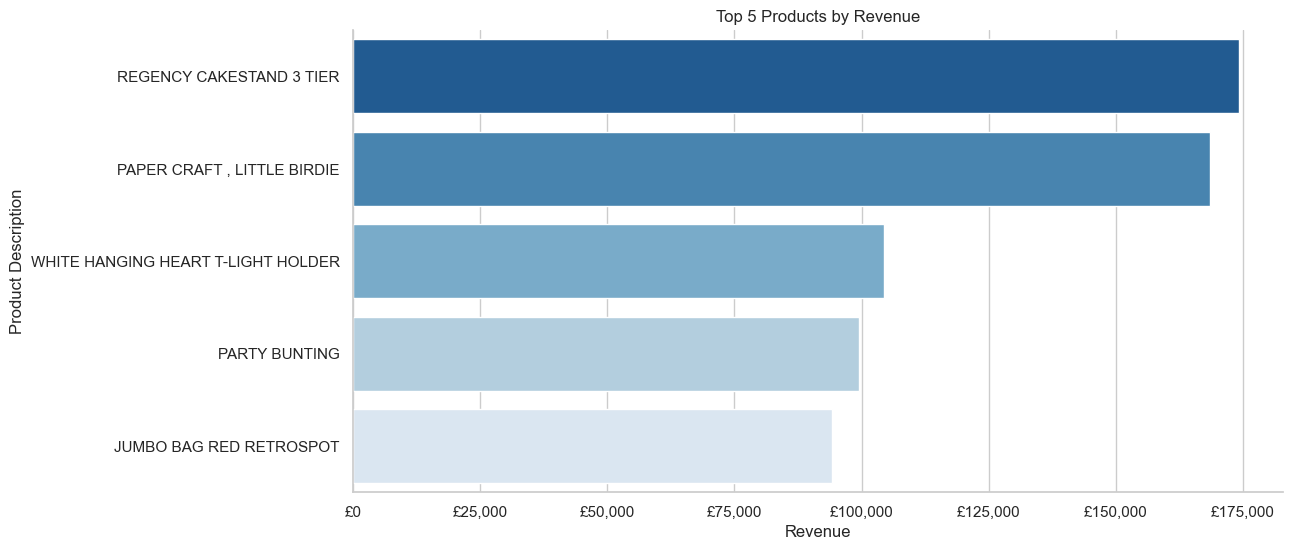

In [261]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_products_revenue,
    x="Revenue",
    y="Description",
    hue="Description",
    palette="Blues_r",
    legend=False,
)

revenue_formatter = FuncFormatter(lambda x, _: f"£{x:,.0f}")
plt.gca().xaxis.set_major_formatter(revenue_formatter)

plt.title("Top 5 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product Description")

sns.despine()
plt.show()

REGENCY CAKESTAND 3 TIER generated the highest product revenue at approximately £174,157, followed by PAPER CRAFT, LITTLE BIRDIE at approximately £168,470. However, the revenue generated by PAPER CRAFT, LITTLE BIRDIE resulted from a single unusually large transaction, meaning its high revenue does not represent repeated customer demand. JUMBO BAG RED RETROSPOT appears within the top five products across total quantity sold, transaction frequency and revenue, indicating consistently strong performance across multiple measures.

---

# Section 6 - Customer Analysis

In this section, I will analyse customer purchasing behaviour by examining customer revenue, transaction frequency and purchasing activity. This will help identify high-value and frequently purchasing customers and determine whether customer performance is concentrated among a small number of customers.

In [262]:
top_customers_revenue = (
    df.groupby("CustomerID")["Revenue"]
    .sum()
    .reset_index()
    .sort_values("Revenue", ascending=False)
    .head()
)

top_customers_revenue

,CustomerID,Revenue
2159,15287,1755388.60
1689,14646,280206.02
4201,18102,259657.30
3728,17450,194390.79
3008,16446,168472.50


In [263]:
df[df["CustomerID"] == 15287]["InvoiceNo"].nunique()

1430

In [264]:
df[df["CustomerID"] == 15287].groupby("InvoiceNo")["Revenue"].sum().sort_values(
    ascending=False
).head()

InvoiceNo
574941    52940.94
576365    50653.91
548203    21627.72
539750    18745.86
573585    16874.58
Name: Revenue, dtype: float64

In [265]:
top_customers_revenue["CustomerID"] = top_customers_revenue["CustomerID"].astype(str)

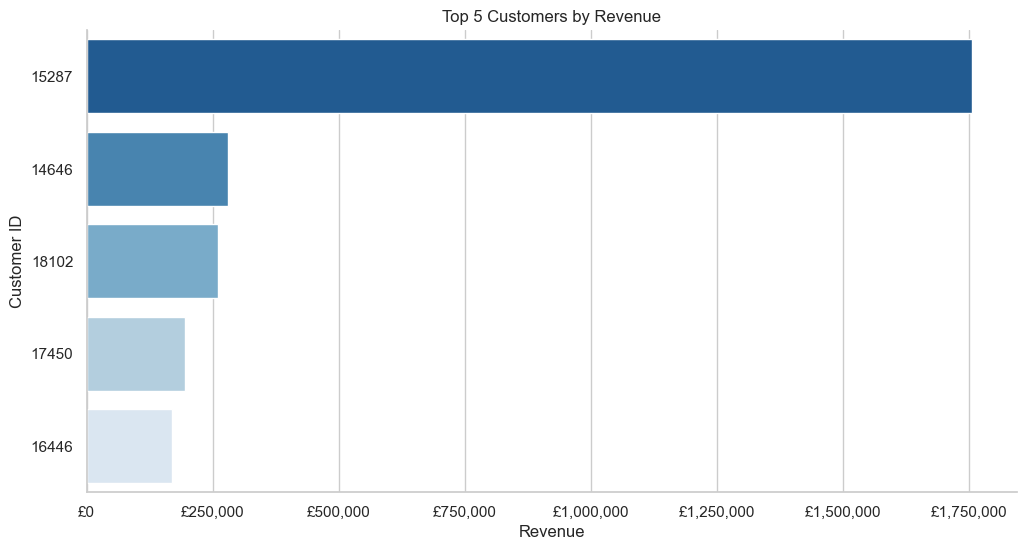

In [266]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_customers_revenue,
    x="Revenue",
    y="CustomerID",
    hue="CustomerID",
    palette="Blues_r",
    legend=False,
)

plt.title("Top 5 Customers by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Customer ID")

plt.gca().xaxis.set_major_formatter(revenue_formatter)

sns.despine()

plt.show()

Customer 15287 generated the highest total revenue at approximately £1.76 million, substantially exceeding the other top customers. Further investigation showed that this customer appeared across 1,430 unique transactions, with their largest individual transaction generating approximately £52,941. This indicates that their high total revenue is not driven by a single unusually large transaction, but reflects substantial repeated purchasing activity. Customer 14646 generated the second-highest revenue at approximately £280,206, followed by customer 18102 at approximately £259,657.

Total customer revenue identifies the customers contributing the greatest monetary value, but does not show how frequently they purchase. Transaction frequency will therefore also be examined to distinguish customers with repeated purchasing activity from those generating high revenue through fewer transactions.

In [267]:
top_customers_transactions = (
    df.groupby("CustomerID")["InvoiceNo"]
    .nunique()
    .reset_index()
    .sort_values("InvoiceNo", ascending=False)
    .head()
)
top_customers_transactions

,CustomerID,InvoiceNo
2159,15287,1430
326,12748,209
1879,14911,201
4010,17841,124
562,13089,97


In [268]:
top_customers_transactions["CustomerID"] = top_customers_transactions[
    "CustomerID"
].astype(str)

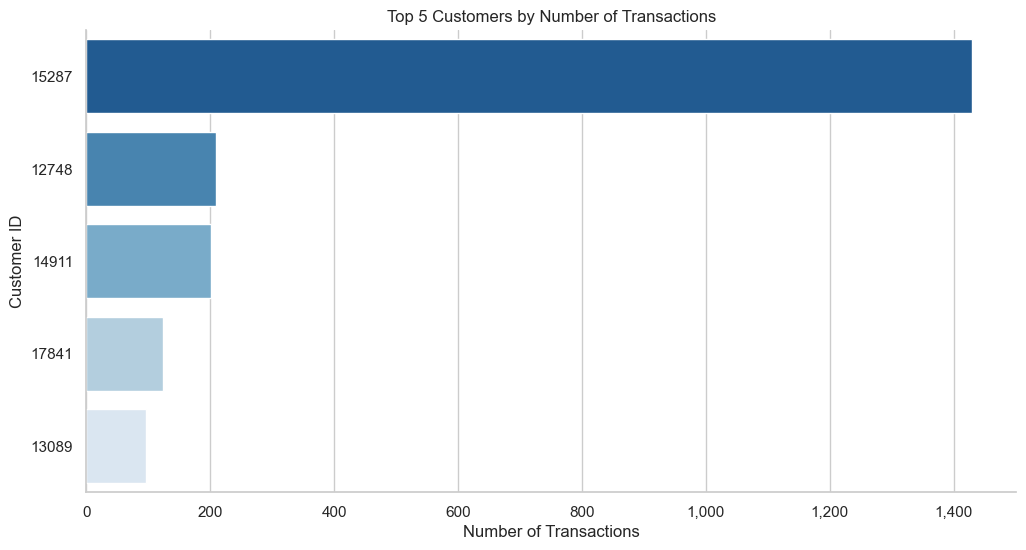

In [269]:
plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_customers_transactions,
    x="InvoiceNo",
    y="CustomerID",
    hue="CustomerID",
    palette="Blues_r",
    legend=False,
)
plt.title("Top 5 Customers by Number of Transactions")
plt.xlabel("Number of Transactions")
plt.ylabel("Customer ID")
plt.gca().xaxis.set_major_formatter(transaction_formatter)
sns.despine()
plt.show()

Customer 15287 has the highest transaction frequency, appearing across 1,430 unique transactions, substantially exceeding customer 12748 in second place with 209 transactions. Customer 15287 also generated the highest total revenue, indicating that their high customer value is supported by substantial repeat purchasing activity rather than a single unusually large transaction. The remaining customers with the highest transaction frequencies differ from those ranked highest by revenue, suggesting that frequent purchasing does not necessarily result in the highest overall customer revenue.

Average transaction value will also be explored as another measure of customer purchasing behaviour. However, this metric will be interpreted alongside transaction frequency, as customers with very few purchases may appear disproportionately valuable if they have made a single unusually large transaction.

In [270]:
customer_transactions = (
    df.groupby(["CustomerID", "InvoiceNo"])["Revenue"].sum().reset_index()
)

customer_transactions

,CustomerID,InvoiceNo,Revenue
0,12346,541431,77183.60
1,12347,537626,711.79
2,12347,542237,475.39
3,12347,549222,636.25
4,12347,556201,382.52
...,...,...,...
19955,18283,579673,220.31
19956,18283,580872,208.00
19957,18287,554065,765.28
19958,18287,570715,1001.32


In [271]:
top_customers_avg_transaction = (
    customer_transactions.groupby("CustomerID")["Revenue"]
    .mean()
    .reset_index()
    .sort_values("Revenue", ascending=False)
    .head()
)

top_customers_avg_transaction

,CustomerID,Revenue
3008,16446,84236.250000
0,12346,77183.600000
2502,15749,14844.766667
2011,15098,13305.500000
10,12357,6207.670000


In [272]:
customer_transactions[
    customer_transactions["CustomerID"].isin(
        top_customers_avg_transaction["CustomerID"]
    )
]

,CustomerID,InvoiceNo,Revenue
0,12346,541431,77183.60
28,12357,574740,6207.67
9018,15098,556442,297.00
9019,15098,556444,38970.00
9020,15098,556446,649.50
12323,15749,540815,15160.90
12324,15749,540818,7837.50
12325,15749,550461,21535.90
14315,16446,553573,2.90
14316,16446,581483,168469.60


The customers with the highest average transaction values were investigated further to determine whether these averages reflected consistent purchasing behaviour. The results showed that these customers generally had very few transactions, with some averages heavily influenced by a single high-value purchase. Therefore, average transaction value was not used as a primary measure of customer performance, as it may overstate the importance of customers with limited purchasing history.

Overall, customer performance is highly concentrated around customer 15287, who leads both revenue and transaction frequency, while the analysis also demonstrates that high average transaction values should be interpreted cautiously when customers have limited purchasing histories.

---

# Section 7 - Geographic Performance

In this section, I will analyse geographic performance by comparing revenue and sales volume across countries. This will help identify the strongest-performing markets and determine how sales activity varies across different geographic regions.

In [273]:
df["Country"].nunique()

38

In [274]:
df["Country"].unique()

array(['United Kingdom', 'France', 'Australia', 'Netherlands', 'Germany',
       'Norway', 'EIRE', 'Switzerland', 'Spain', 'Poland', 'Portugal',
       'Italy', 'Belgium', 'Lithuania', 'Japan', 'Iceland',
       'Channel Islands', 'Denmark', 'Cyprus', 'Sweden', 'Finland',
       'Austria', 'Bahrain', 'Israel', 'Greece', 'Hong Kong', 'Singapore',
       'Lebanon', 'United Arab Emirates', 'Saudi Arabia',
       'Czech Republic', 'Canada', 'Unspecified', 'Brazil', 'USA',
       'European Community', 'Malta', 'RSA'], dtype=object)

The dataset contains 38 geographic categories. Before comparing performance, the country values were inspected to identify any categories that may require consideration during the analysis. Most values represent individual countries or geographic markets, although Unspecified and European Community do not represent individual countries and will therefore be excluded from international country comparisons.

Total revenue will first be aggregated by country to identify the markets contributing the most revenue. The United Kingdom will initially be retained to understand its contribution to overall business performance before focusing specifically on international markets.

In [275]:
country_revenue = (
    df.groupby("Country")["Revenue"]
    .sum()
    .reset_index()
    .sort_values("Revenue", ascending=False)
)
country_revenue

,Country,Revenue
36,United Kingdom,9001744.094
24,Netherlands,285446.340
10,EIRE,283140.520
14,Germany,228678.400
13,France,209625.370
0,Australia,138453.810
31,Spain,61558.560
33,Switzerland,57067.600
3,Belgium,41196.340
32,Sweden,38367.830


In [276]:
uk_revenue = country_revenue[country_revenue["Country"] == "United Kingdom"][
    "Revenue"
].values[0]
uk_revenue

np.float64(9001744.094)

In [277]:
uk_revenue_percentage = ((uk_revenue / total_revenue) * 100).round(2)
uk_revenue_percentage

np.float64(84.59)

In [278]:
international_revenue = (
    df[~df["Country"].isin(["United Kingdom", "Unspecified", "European Community"])]
    .groupby("Country")["Revenue"]
    .sum()
    .reset_index()
    .sort_values("Revenue", ascending=False)
)
international_revenue

,Country,Revenue
23,Netherlands,285446.34
10,EIRE,283140.52
13,Germany,228678.40
12,France,209625.37
0,Australia,138453.81
30,Spain,61558.56
32,Switzerland,57067.60
3,Belgium,41196.34
31,Sweden,38367.83
19,Japan,37416.37


In [279]:
top_international_revenue = international_revenue.head(10)

top_international_revenue

,Country,Revenue
23,Netherlands,285446.34
10,EIRE,283140.52
13,Germany,228678.40
12,France,209625.37
0,Australia,138453.81
30,Spain,61558.56
32,Switzerland,57067.60
3,Belgium,41196.34
31,Sweden,38367.83
19,Japan,37416.37


The United Kingdom generated approximately 84.59% of total revenue, showing that overall revenue is heavily concentrated within the domestic market. To allow differences between international markets to be compared more clearly, the United Kingdom was excluded from the following ranking. Unspecified and European Community were also excluded because they do not represent individual countries.

In [280]:
fig = px.bar(
    top_international_revenue,
    x="Revenue",
    y="Country",
    orientation="h",
    title="Top 10 International Markets by Revenue",
    labels={"Revenue": "Revenue (£)", "Country": "Country"},
    text="Revenue",
)

fig.update_traces(texttemplate="£%{text:,.0f}", textposition="outside")

fig.update_layout(yaxis={"categoryorder": "total ascending"}, width=1000, height=600)

fig.update_xaxes(range=[0, 330000])

fig.show()

Among international markets, the Netherlands generated the highest revenue at approximately £285,446, closely followed by EIRE at approximately £283,141. Germany and France also performed strongly, generating approximately £228,678 and £209,625 respectively. Revenue then falls to approximately £138,454 for Australia, followed by a substantial decrease among the remaining markets. This indicates that international revenue is concentrated among a relatively small number of countries, particularly the Netherlands, EIRE, Germany and France.

Revenue alone does not show the level of product demand within each market, as differences in product prices and purchasing patterns can affect the amount of revenue generated. Sales volume will therefore also be analysed by country to identify the markets purchasing the greatest number of units and to compare whether geographic patterns in sales volume are consistent with those observed for revenue.

In [281]:
country_sales_volume = (
    df.groupby("Country")["Quantity"]
    .sum()
    .reset_index()
    .sort_values("Quantity", ascending=False)
)

country_sales_volume

,Country,Quantity
36,United Kingdom,4646906
24,Netherlands,200361
10,EIRE,147007
14,Germany,119154
13,France,112060
0,Australia,83891
32,Sweden,36078
33,Switzerland,30617
31,Spain,27933
20,Japan,26016


In [282]:
uk_sales_volume = country_sales_volume[
    country_sales_volume["Country"] == "United Kingdom"
]["Quantity"].values[0]

uk_sales_volume_percentage = ((uk_sales_volume / total_sales_volume) * 100).round(2)

uk_sales_volume_percentage

np.float64(83.39)

The United Kingdom accounts for 83.39% of total units sold, again demonstrating the strong concentration of business activity within the domestic market. As with the revenue analysis, the United Kingdom, Unspecified and European Community will be excluded from the international sales-volume comparison so that differences between individual international markets can be examined more clearly.

In [283]:
international_sales_volume = (
    df[~df["Country"].isin(["United Kingdom", "Unspecified", "European Community"])]
    .groupby("Country")["Quantity"]
    .sum()
    .reset_index()
    .sort_values("Quantity", ascending=False)
)

international_sales_volume

,Country,Quantity
23,Netherlands,200361
10,EIRE,147007
13,Germany,119154
12,France,112060
0,Australia,83891
31,Sweden,36078
32,Switzerland,30617
30,Spain,27933
19,Japan,26016
3,Belgium,23237


In [284]:
top_international_sales_volume = international_sales_volume.head(10)

In [285]:
fig = px.bar(
    top_international_sales_volume,
    x="Quantity",
    y="Country",
    orientation="h",
    title="Top 10 International Markets by Sales Volume",
    labels={"Quantity": "Units Sold", "Country": "Country"},
    text="Quantity",
)

fig.update_traces(texttemplate="%{text:,.0f}", textposition="outside")

fig.update_layout(yaxis={"categoryorder": "total ascending"}, width=1000, height=600)

fig.update_xaxes(range=[0, 230000])

fig.show()

The United Kingdom accounted for 83.39% of total sales volume, which is similar to its 84.59% share of total revenue, confirming that business activity is heavily concentrated within the domestic market. Among international markets, the Netherlands recorded the highest sales volume with 200,361 units sold, followed by EIRE (147,007), Germany (119,154), France (112,060) and Australia (83,891). These are also the five highest-performing international markets by revenue and appear in the same order, showing that the leading international markets by sales volume are also the leading markets by revenue.

---

# Section 8 - Statistical Analysis and Distributions

In this section, I will explore the statistical characteristics and distributions of key numerical variables within the dataset. Descriptive statistics including the mean, median, standard deviation and variance will be used to understand central tendency and variability. Distributions will also be visualised to identify skewness and extreme values that may influence summary statistics. Relationships between relevant numerical variables will then be explored to determine whether patterns observed during the earlier exploratory analysis are supported by the data.

### Statistical Concepts Used

- **Mean:** The average value, calculated by adding all values and dividing by the number of observations. It can be influenced by very high or very low values.
- **Median:** The middle value when the data is ordered. It is often more representative than the mean when a distribution is strongly skewed.
- **Standard deviation and variance:** Measures of how spread out values are around the mean. Higher values indicate greater variation in the data.
- **Probability:** The likelihood of an event occurring. In this analysis, probability is used to measure how likely a randomly selected transaction is to exceed a chosen revenue threshold.
- **Hypothesis testing:** A statistical method used to test whether there is enough evidence in the data to reject a null hypothesis. A significance level of 0.05 will later be used to assess the hypothesis test.

In [286]:
transaction_revenue = df.groupby("InvoiceNo")["Revenue"].sum().reset_index()

transaction_revenue

,InvoiceNo,Revenue
0,536365,139.12
1,536366,22.20
2,536367,278.73
3,536368,70.05
4,536369,17.85
...,...,...
19955,581584,140.64
19956,581585,329.05
19957,581586,339.20
19958,581587,249.45


In [287]:
transaction_revenue.describe()

,Revenue
count,19960.000000
mean,533.171884
std,1780.412288
min,0.380000
25%,151.695000
50%,303.300000
75%,493.462500
max,168469.600000


In [288]:
transaction_revenue["Revenue"].var()

np.float64(3169867.9136426435)

Descriptive statistics were used to understand the central tendency and variability of transaction revenue.

The mean transaction value is £533.17, while the median is considerably lower at £303.30. The standard deviation is £1,780.41 and the variance is approximately 3,169,867.91. In addition, 75% of transactions generated £493.46 or less, while the maximum transaction value was £168,469.60. The substantial difference between the mean and median, together with the high variability and extreme maximum value, suggests that transaction revenue is positively skewed, with a relatively small number of high-value transactions pulling the mean upwards.

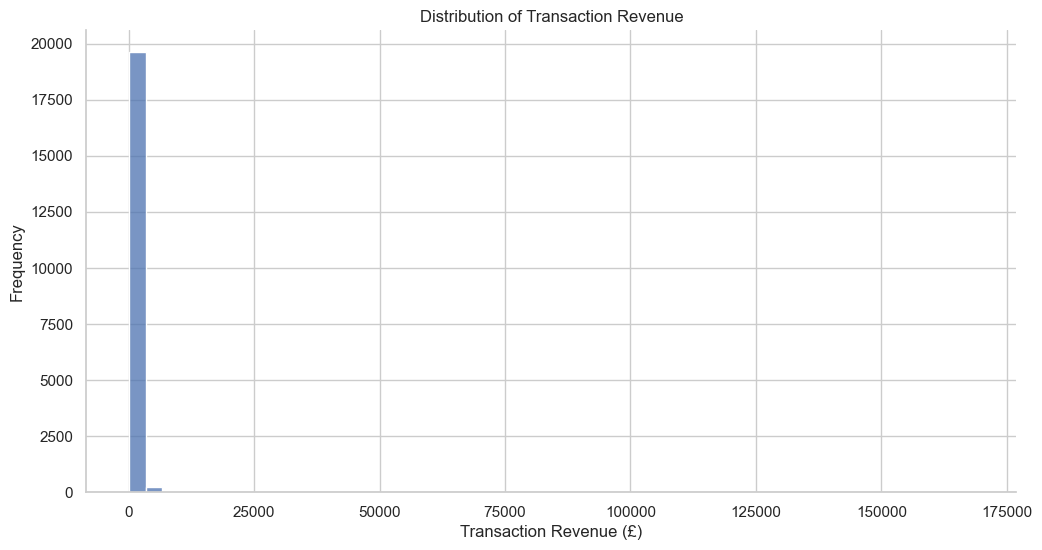

In [289]:
plt.figure(figsize=(12, 6))

sns.histplot(data=transaction_revenue, x="Revenue", bins=50)

plt.title("Distribution of Transaction Revenue")
plt.xlabel("Transaction Revenue (£)")
plt.ylabel("Frequency")

sns.despine()
plt.show()

The full transaction revenue distribution is heavily right-skewed. Most transactions are concentrated at the lower end of the revenue range, while a small number of extremely high-value transactions extend the distribution considerably. This causes the majority of observations to appear compressed in the histogram and supports the earlier finding that the mean transaction value is influenced by unusually high-value transactions.

To examine the distribution of typical transaction values more clearly, a focused view of the main transaction range will be created while retaining the full dataset for the overall analysis.

In [290]:
transaction_revenue["Revenue"].quantile([0.90, 0.95, 0.99])

0.90     938.3910
0.95    1585.9210
0.99    4821.1654
Name: Revenue, dtype: float64

The 90th, 95th and 99th percentiles were examined to determine an appropriate range for a more focused visualisation. The results show that 99% of transactions generated approximately £4,821.17 or less, despite the maximum transaction value being £168,469.60. Therefore, the lower 99% of transaction values will be visualised separately to provide a clearer view of the main distribution. This filtering is applied only to the visualisation and does not remove high-value transactions from the underlying analysis.

In [291]:
revenue_99th_percentile = transaction_revenue["Revenue"].quantile(0.99)

typical_transaction_revenue = transaction_revenue[
    transaction_revenue["Revenue"] <= revenue_99th_percentile
]

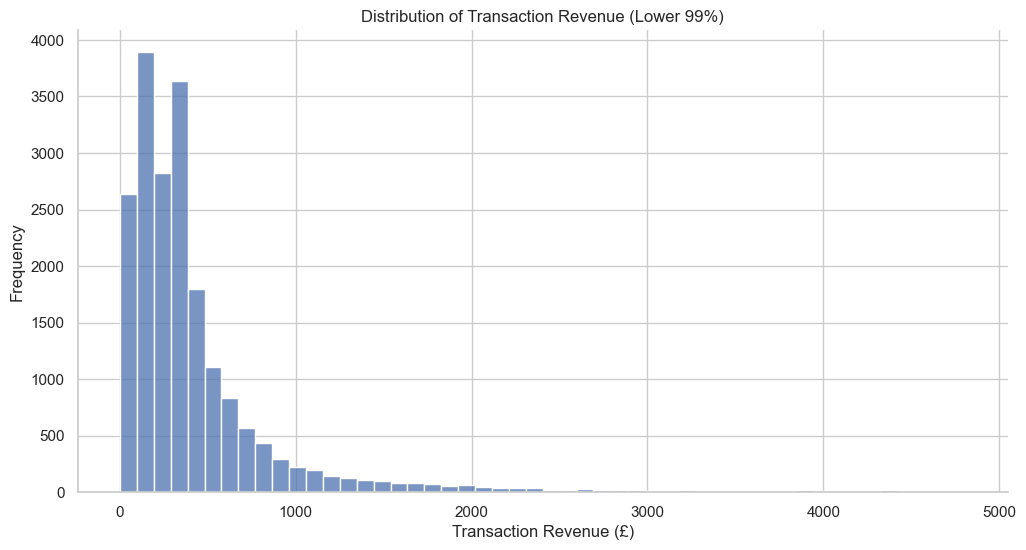

In [292]:
plt.figure(figsize=(12, 6))

sns.histplot(data=typical_transaction_revenue, x="Revenue", bins=50)

plt.title("Distribution of Transaction Revenue (Lower 99%)")
plt.xlabel("Transaction Revenue (£)")
plt.ylabel("Frequency")

sns.despine()
plt.show()

The focused distribution confirms that transaction revenue remains strongly right-skewed even after excluding the upper 1% from the visualisation. Most transactions are concentrated at relatively low revenue values, while progressively fewer transactions occur as revenue increases, creating a long right tail.

This supports the descriptive statistics, where the mean transaction value (£533.17) was substantially higher than the median (£303.30). Therefore, the median provides a more representative measure of a typical transaction value in this dataset, while the mean is more sensitive to the relatively small number of high-value transactions.

### Transaction Revenue Outliers

The transaction revenue distribution shows a long right tail containing a relatively small number of high-value transactions. To investigate these extreme values further, a boxplot will be used to visualise the spread of transaction revenue and identify potential outliers.

The Interquartile Range (IQR) method will then be used to calculate an objective threshold for potential outliers. The IQR represents the range between the first quartile (Q1) and third quartile (Q3), containing the middle 50% of observations. Values above Q3 + 1.5 × IQR or below Q1 - 1.5 × IQR can be identified as potential outliers.

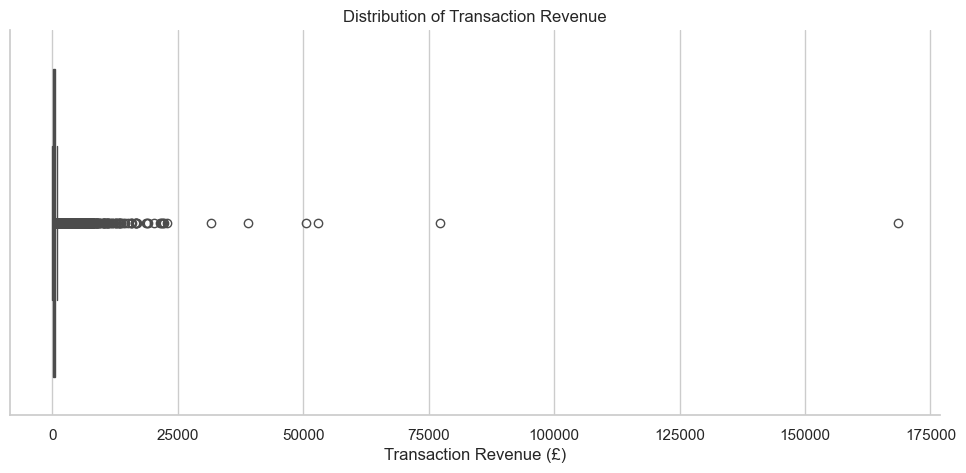

In [293]:
plt.figure(figsize=(12, 5))

sns.boxplot(data=transaction_revenue, x="Revenue")

plt.title("Distribution of Transaction Revenue")
plt.xlabel("Transaction Revenue (£)")

sns.despine()
plt.show()

In [294]:
Q1 = transaction_revenue["Revenue"].quantile(0.25)
Q3 = transaction_revenue["Revenue"].quantile(0.75)

IQR = Q3 - Q1

print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")

Q1: 151.69500000000002, Q3: 493.4625, IQR: 341.7674999999999


In [295]:
lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

print(f"Lower bound: {lower_bound:.2f}")
print(f"Upper bound: {upper_bound:.2f}")

Lower bound: -360.96
Upper bound: 1006.11


In [296]:
transaction_outliers = transaction_revenue[transaction_revenue["Revenue"] > upper_bound]

transaction_outliers

,InvoiceNo,Revenue
20,536387,3193.92
23,536390,1825.74
26,536394,1024.68
54,536477,2474.74
72,536532,1919.14
...,...,...
19930,581492,7689.23
19933,581495,1203.90
19935,581497,3217.20
19936,581498,5664.89


In [297]:
outlier_percentage = (len(transaction_outliers) / len(transaction_revenue)) * 100

print(f"Potential outliers: {len(transaction_outliers)}")
print(f"Percentage of transactions: {outlier_percentage:.2f}%")

Potential outliers: 1811
Percentage of transactions: 9.07%


Using the IQR method, transactions above £1,006.11 were identified as potential outliers. This included 1,811 transactions, which represents 9.07% of all transactions. No lower outliers were found because the lower boundary was negative, while all transaction revenue values were positive.

However, these transactions are not necessarily errors. Some customers may simply place larger or higher-value orders, and removing all transactions above £1,006.11 would remove a noticeable amount of genuine sales data. For this reason, the transactions were kept in the dataset. Focused visualisations were used instead when the very high values made the main patterns difficult to see.

Transaction quantity will be analysed to understand the typical number of items purchased within an order and how much order sizes vary. As each invoice can contain multiple product lines, quantity is first summed by InvoiceNo to calculate the total number of units purchased in each transaction.

In [298]:
transaction_quantity = df.groupby("InvoiceNo")["Quantity"].sum().reset_index()

transaction_quantity

,InvoiceNo,Quantity
0,536365,40
1,536366,12
2,536367,83
3,536368,15
4,536369,3
...,...,...
19955,581584,120
19956,581585,278
19957,581586,66
19958,581587,105


In [299]:
transaction_quantity.describe()

,Quantity
count,19960.000000
mean,279.179359
std,955.011810
min,1.000000
25%,69.000000
50%,150.000000
75%,296.000000
max,80995.000000


The average transaction contained approximately 279 units, while the median was lower at 150 units. In addition, 75% of transactions contained 296 units or fewer, compared with a maximum of 80,995 units. The large difference between the mean and median, together with the high maximum value and standard deviation, suggests that transaction quantity is also strongly right-skewed and influenced by a small number of very large orders.

### Relationship Between Transaction Quantity and Revenue

After examining the distributions individually, transaction quantity and revenue were combined using `InvoiceNo`. This allows the relationship between the number of units purchased and the revenue generated by each transaction to be explored.

The aim is to determine whether transactions containing larger quantities generally generate higher revenue.

In [300]:
transaction_analysis = transaction_revenue.merge(transaction_quantity, on="InvoiceNo")

transaction_analysis

,InvoiceNo,Revenue,Quantity
0,536365,139.12,40
1,536366,22.20,12
2,536367,278.73,83
3,536368,70.05,15
4,536369,17.85,3
...,...,...,...
19955,581584,140.64,120
19956,581585,329.05,278
19957,581586,339.20,66
19958,581587,249.45,105


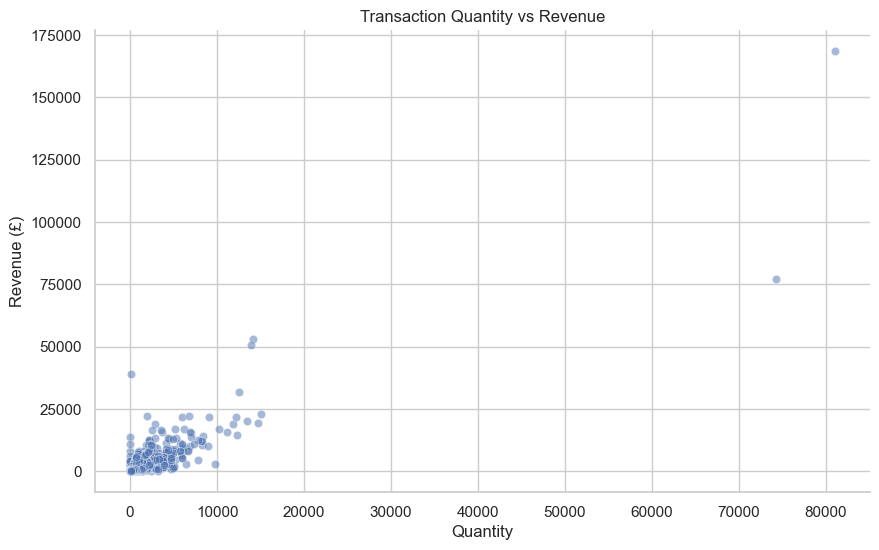

In [301]:
plt.figure(figsize=(10, 6))

sns.scatterplot(data=transaction_analysis, x="Quantity", y="Revenue", alpha=0.5)

plt.title("Transaction Quantity vs Revenue")
plt.xlabel("Quantity")
plt.ylabel("Revenue (£)")

sns.despine()
plt.show()

In [302]:
transaction_analysis[["Quantity", "Revenue"]].corr()

,Quantity,Revenue
Quantity,1.000000,0.882687
Revenue,0.882687,1.000000


The Pearson correlation coefficient between transaction quantity and revenue is 0.883, indicating a strong positive linear relationship. This suggests that transactions containing larger quantities generally generate higher revenue.

However, both quantity and revenue contain extreme values and have strongly right-skewed distributions. As Pearson correlation can be affected by extreme values, Spearman correlation will also be calculated to check whether the positive relationship remains when comparing the ranked values.

In [303]:
transaction_analysis[["Quantity", "Revenue"]].corr(method="spearman")

,Quantity,Revenue
Quantity,1.000000,0.838984
Revenue,0.838984,1.000000


The Spearman correlation coefficient is 0.839, which also shows a strong positive relationship between transaction quantity and revenue. This is slightly lower than the Pearson correlation of 0.883, suggesting that the extreme values may have some influence on the Pearson result.

However, both measures show a strong positive relationship. This indicates that transactions with larger quantities generally generate higher revenue, and that this relationship is not only caused by the small number of very large transactions.

### Probability of a High-Value Transaction

To apply probability to the transaction data, the probability of a randomly selected transaction generating more than £1,000 in revenue will be calculated. This provides a simple measure of how common higher-value transactions are within the dataset.

In [304]:
high_value_transactions = transaction_revenue[transaction_revenue["Revenue"] > 1000]

In [305]:
high_value_probability = len(high_value_transactions) / len(transaction_revenue)

high_value_percentage = high_value_probability * 100

print(f"Probability: {high_value_probability:.4f}")
print(f"Percentage: {high_value_percentage:.2f}%")

Probability: 0.0918
Percentage: 9.18%


The probability of a randomly selected transaction generating more than £1,000 in revenue is 0.0918, or 9.18%. This means that approximately 9 in every 100 transactions are worth more than £1,000.

This also supports the earlier distribution analysis, as higher-value transactions make up a relatively small proportion of all transactions, while most transactions are concentrated at lower revenue values.

### Section 8 Summary

The statistical analysis showed that both transaction revenue and transaction quantity are strongly right-skewed, with a relatively small number of large transactions influencing the mean. For transaction revenue, the median of £303.30 therefore provides a more representative measure of a typical transaction than the mean of £533.17.

The IQR analysis identified 9.07% of transactions as potential revenue outliers. However, these transactions were retained because there was no evidence that they represented errors, and removing them could exclude genuine high-value purchasing activity.

Transaction quantity and revenue also showed a strong positive relationship, with Pearson and Spearman correlation coefficients of 0.883 and 0.839 respectively. This indicates that transactions containing larger quantities generally generate higher revenue. Finally, the probability analysis found that 9.18% of transactions generated more than £1,000, further showing that high-value transactions represent a relatively small proportion of overall purchasing activity.

---

# Section 9 - Hypothesis Testing

Hypothesis testing will be used to investigate whether there is a statistically significant difference in transaction revenue between UK and international transactions.

Earlier analysis showed that the United Kingdom generates the majority of total revenue. However, this may be influenced by the larger number of UK transactions and does not necessarily mean that individual UK transactions have higher values. Comparing transaction revenue between the two groups provides further insight into customer purchasing behaviour across markets.

Null Hypothesis (H₀): There is no significant difference in transaction revenue between UK and international transactions.

Alternative Hypothesis (H₁): There is a significant difference in transaction revenue between UK and international transactions.

A significance level of α = 0.05 will be used. If the p-value is below 0.05, the null hypothesis will be rejected. If the p-value is 0.05 or above, there will not be enough evidence to reject the null hypothesis.

In [306]:
country_transactions = (
    df.groupby(["InvoiceNo", "Country"])["Revenue"].sum().reset_index()
)

country_transactions

,InvoiceNo,Country,Revenue
0,536365,United Kingdom,139.12
1,536366,United Kingdom,22.20
2,536367,United Kingdom,278.73
3,536368,United Kingdom,70.05
4,536369,United Kingdom,17.85
...,...,...,...
19955,581584,United Kingdom,140.64
19956,581585,United Kingdom,329.05
19957,581586,United Kingdom,339.20
19958,581587,France,249.45


In [307]:
uk_transactions = country_transactions[
    country_transactions["Country"] == "United Kingdom"
]

uk_transactions

,InvoiceNo,Country,Revenue
0,536365,United Kingdom,139.12
1,536366,United Kingdom,22.20
2,536367,United Kingdom,278.73
3,536368,United Kingdom,70.05
4,536369,United Kingdom,17.85
...,...,...,...
19954,581583,United Kingdom,124.60
19955,581584,United Kingdom,140.64
19956,581585,United Kingdom,329.05
19957,581586,United Kingdom,339.20


In [308]:
international_transactions = country_transactions[
    ~country_transactions["Country"].isin(
        ["United Kingdom", "Unspecified", "European Community"]
    )
]

international_transactions

,InvoiceNo,Country,Revenue
5,536370,France,855.86
22,536389,Australia,358.25
35,536403,Netherlands,192.60
67,536527,Germany,261.48
72,536532,Norway,1919.14
...,...,...,...
19932,581494,Germany,339.14
19945,581570,Germany,224.95
19948,581574,Germany,277.08
19949,581578,Germany,848.55


In [309]:
print(f"UK transactions: {len(uk_transactions)}")
print(f"International transactions: {len(international_transactions)}")

UK transactions: 18019
International transactions: 1924


In [310]:
transaction_comparison = pd.DataFrame(
    {
        "UK": uk_transactions["Revenue"].describe(),
        "International": international_transactions["Revenue"].describe(),
    }
)

transaction_comparison

,UK,International
count,18019.000000,1924.000000
mean,499.569571,849.441538
std,1781.520653,1746.775804
min,0.380000,1.450000
25%,147.060000,228.862500
50%,299.950000,427.530000
75%,465.315000,793.730000
max,168469.600000,22775.930000


The descriptive statistics show that international transactions generally have higher revenue values than UK transactions. The median international transaction value was £427.53 compared with £299.95 for UK transactions. The mean was also higher internationally at £849.44 compared with £499.57 in the UK.

The international values were higher across the first, second and third quartiles, suggesting that the difference is not only caused by a small number of high-value transactions. However, both groups contain large maximum values and the means are considerably higher than the medians, indicating that the revenue distributions are right-skewed.

A statistical test will therefore be used to determine whether the observed difference between UK and international transaction revenue is statistically significant.

In [311]:
uk_test = uk_transactions.copy()
uk_test["Market"] = "UK"

In [312]:
international_test = international_transactions.copy()
international_test["Market"] = "International"

In [313]:
market_transactions = pd.concat([uk_test, international_test], ignore_index=True)

market_transactions

,InvoiceNo,Country,Revenue,Market
0,536365,United Kingdom,139.12,UK
1,536366,United Kingdom,22.20,UK
2,536367,United Kingdom,278.73,UK
3,536368,United Kingdom,70.05,UK
4,536369,United Kingdom,17.85,UK
...,...,...,...,...
19938,581494,Germany,339.14,International
19939,581570,Germany,224.95,International
19940,581574,Germany,277.08,International
19941,581578,Germany,848.55,International


A boxplot was used to compare the distribution of transaction revenue between UK and international markets. This allows differences in the median, spread and extreme values between the two groups to be compared before selecting an appropriate statistical test.

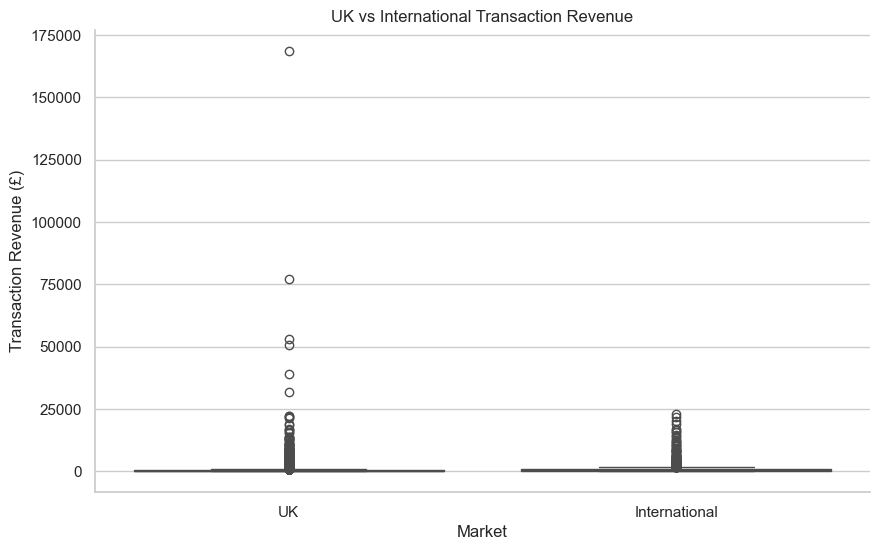

In [314]:
plt.figure(figsize=(10, 6))

sns.boxplot(data=market_transactions, x="Market", y="Revenue")

plt.title("UK vs International Transaction Revenue")
plt.xlabel("Market")
plt.ylabel("Transaction Revenue (£)")

sns.despine()
plt.show()

The full boxplot shows that both UK and international transaction revenue contain high-value transactions. The UK contains particularly large values, including the maximum transaction of £168,469.60. These extreme values compress the main boxes near the bottom of the chart, making the typical transaction values difficult to compare.

A focused view will therefore be used to examine the main distributions more clearly. The high-value transactions will only be excluded from the visualisation and will remain in the dataset used for the analysis.

In [315]:
revenue_99 = market_transactions["Revenue"].quantile(0.99)

revenue_99

np.float64(4826.4251999999415)

In [316]:
focused_market_transactions = market_transactions[
    market_transactions["Revenue"] <= revenue_99
]

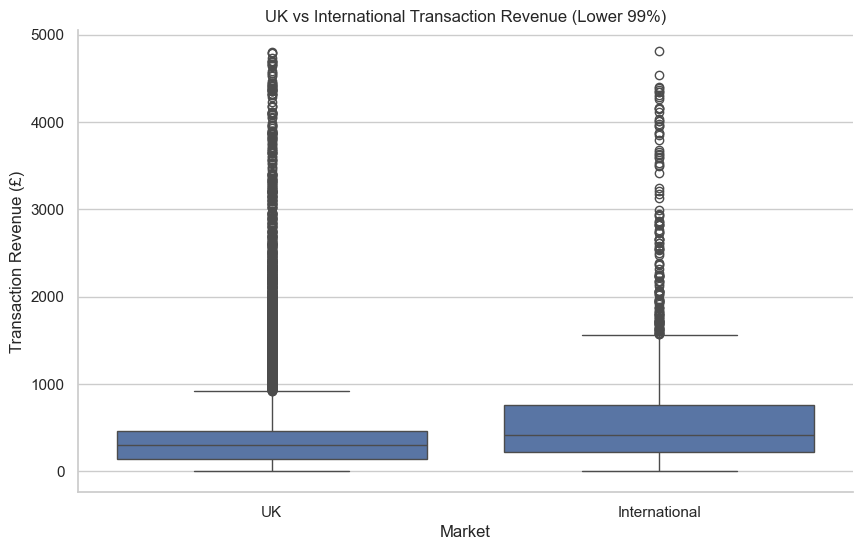

In [317]:
plt.figure(figsize=(10, 6))

sns.boxplot(data=focused_market_transactions, x="Market", y="Revenue")

plt.title("UK vs International Transaction Revenue (Lower 99%)")
plt.xlabel("Market")
plt.ylabel("Transaction Revenue (£)")

sns.despine()
plt.show()

The focused boxplot makes the difference between the two markets clearer. International transactions have a higher median transaction value than UK transactions, and the middle 50% of international transactions is also generally higher.

Both groups still contain many high-value transactions and show right-skewed distributions, even after the upper 1% is excluded from the visualisation. This supports the earlier finding that transaction revenue is not normally distributed and suggests that a non-parametric test may be more suitable for comparing the two groups.

As the comparison involves two independent groups with strongly right-skewed revenue distributions, the Mann–Whitney U test was selected as a non-parametric method for testing whether the distributions differ.

In [318]:
statistic, p_value = mannwhitneyu(
    uk_transactions["Revenue"],
    international_transactions["Revenue"],
    alternative="two-sided",
)

print(f"U statistic: {statistic:.2f}")
print(f"P-value: {p_value:.2e}")

U statistic: 12685442.50
P-value: 1.47e-83


The Mann–Whitney U test produced a p-value of $1.47 \times 10^{-83}$, which is far below the significance level of 0.05. Therefore, the null hypothesis is rejected, providing strong evidence of a statistically significant difference in transaction revenue between UK and international transactions.

The descriptive analysis showed that international transactions had a higher median revenue of £427.53, compared with £299.95 for UK transactions. This suggests that although the UK generates the majority of total revenue, individual international transactions tend to have higher values.

This shows that the UK's high overall revenue is strongly supported by its much larger number of transactions, while international markets generate higher typical transaction values.

### Section 9 Summary

The hypothesis test found a statistically significant difference in transaction revenue between UK and international transactions. International transactions had a higher median value of £427.53 compared with £299.95 for UK transactions. The Mann–Whitney U test produced a p-value of $1.47 \times 10^{-83}$, which was below the 0.05 significance level, so the null hypothesis was rejected.

Overall, although the UK generates most of the business's total revenue, this is largely supported by its much higher number of transactions. International transactions tend to generate higher revenue per transaction.

---

# Section 10 - EDA Conclusions & Key Insights

### Key Findings
The exploratory data analysis identified several patterns in the retailer's sales performance. Overall, the dataset generated approximately £10.64 million in revenue from 19,960 transactions and 5.57 million units sold. Transaction revenue was strongly right-skewed, with a mean of £533.17 and a lower median of £303.30, showing that a relatively small number of high-value transactions increased the overall average.

Revenue and sales volume generally followed a similar pattern over time, with both increasing strongly towards the later months of 2011. However, the patterns were not identical, showing that the number of units sold is an important influence on revenue but does not explain revenue performance by itself.

Product performance also varied depending on how performance was measured. REGENCY CAKESTAND 3 TIER generated the highest overall product revenue, while PAPER CRAFT, LITTLE BIRDIE generated a very high amount of revenue from a single transaction. Other products appeared much more frequently across transactions, showing that high revenue or quantity does not always represent consistent customer demand.

Geographically, the UK was the retailer's dominant market, accounting for 84.59% of total revenue and 83.39% of sales volume. Outside the UK, the Netherlands and EIRE were the strongest markets, followed by Germany, France and Australia. However, international transactions had a higher median transaction value of £427.53 compared with £299.95 in the UK. The Mann–Whitney U test found this difference to be statistically significant.

### Business Implications
The strong increase in revenue and sales volume towards the later months of the year suggests that the business should consider seasonal demand when planning stock levels and sales activity.

Product performance should not be judged using revenue alone. Products generating high revenue from repeated transactions may represent more consistent demand than products whose performance is driven by one unusually large order. Looking at revenue, quantity and transaction frequency together would therefore give the business a more complete view of product performance.

Although the UK remains the retailer's largest market, the higher typical transaction values found internationally suggest potential opportunities for further international growth. Markets such as the Netherlands, EIRE, Germany, France and Australia could be investigated further to understand what is driving their performance and whether similar growth could be achieved in other markets.

### Limitations

The dataset covers transactions from December 2010 to December 2011, meaning the analysis is based on approximately one year of historical sales data. In addition, December 2011 only contains transactions up to 9 December, so this month cannot be compared directly with complete months.

The dataset also contains a number of unusually large transactions. These were retained because there was no evidence that they were errors, but they can influence measures such as the mean and make some visualisations difficult to interpret.

The analysis identifies patterns and relationships within the transaction data, but these should not be interpreted as proving that one factor directly causes another. For example, higher transaction quantity is strongly associated with higher revenue, but the different prices of products purchased may also affect the total revenue generated by each transaction.

Finally, the findings are based only on the variables available within the dataset. Other factors such as marketing activity, customer demographics, promotions or wider economic conditions are not included and may also influence sales performance.

### Conclusion
Overall, the EDA shows that the retailer's performance is concentrated across particular customers, products and geographic markets. Revenue is strongly associated with sales volume, but the analysis also shows that transaction value, transaction frequency and market differences provide additional information that cannot be understood from total revenue alone. These findings provide a foundation for the next stages of the project and identify areas where further analysis could support business decision-making.